# <font color='orange'>**TRANSFERENCIA DE APRENDIZAJE:** </font>






In [ ]:
#Importar el modelo de interes
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importar la ruta del DATASET
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = '/content/drive/MyDrive/dataset/train'
test_dir = '/content/drive/MyDrive/dataset/test'

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   vertical_flip=True,
                                   rotation_range=100
                                   )

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print('Probando imagenes')
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size = IMAGE_SIZE,
                                               batch_size = BATCH_SIZE,
                                               class_mode = 'categorical')

test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size = IMAGE_SIZE,
                                             batch_size = BATCH_SIZE,
                                             class_mode = 'categorical')

Probando imagenes
Found 200 images belonging to 5 classes.
Found 50 images belonging to 5 classes.


In [ ]:
imgs, labels = next(train_data)

In [ ]:
labels.shape

(32, 5)

In [ ]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 10, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip( images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

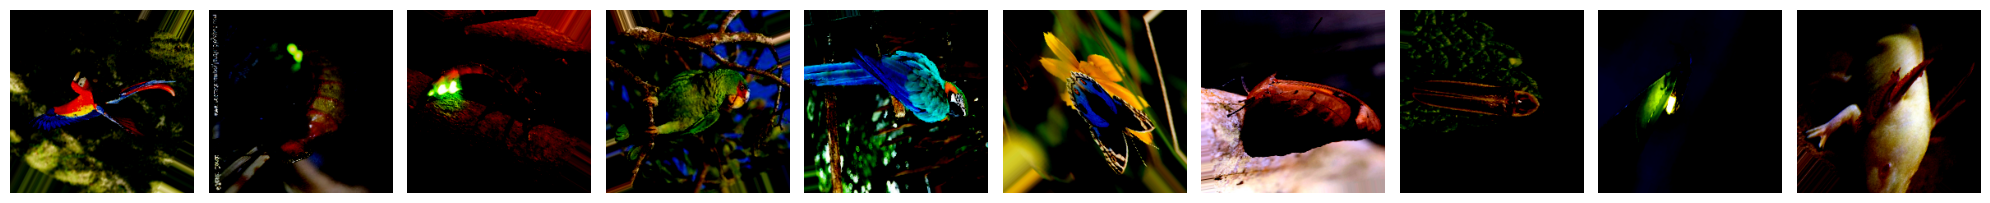

[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]


In [ ]:
plotImages(imgs)
print(labels)
# Etiquetas
# 0 => ajolote 1=>guacamaya 2=>luciernaga 3=>mariposa 4=>perezoso

In [ ]:
#Al cargar un modelo, el argumento "include_top" se puede establecer en False,
#con el objetivo de que  las capas de salida totalmente conectadas (DENSE) del modelo utilizado
#no sean cargadas, esto permite agregar y entrenar una nueva capa de salida
pre_trained_model = MobileNetV2(input_shape=IMAGE_SIZE+(3,), include_top=False, weights='imagenet')

In [ ]:
#Se debe congelar el modelo base, es decir no se ajustarán los pesos del modelo base (pre_trained_model)
pre_trained_model.trainable = False

### <font color='darkviolet'> **Definir utilizando Modelo Funcional de Keras para el entrenamiento**


In [ ]:
pre_trained_model.output

<KerasTensor: shape=(None, 7, 7, 1280) dtype=float32 (created by layer 'out_relu')>

In [ ]:
pre_trained_model.input

<KerasTensor: shape=(None, 224, 224, 3) dtype=float32 (created by layer 'input_1')>

In [ ]:
pre_trained_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[

In [ ]:
# Agregar nuevas capas utlizando la API funcional de KERAS
x = Flatten()(pre_trained_model.output)
x = Dense(2048, activation='relu')(x)
x = Dense(512, activation='relu')(x)
# x = Dense(128, activation='relu')(x)
# x = Dense(128, activation='relu')(x)
x = Dense(16, activation='sigmoid')(x)
predicciones = Dense(5, activation='softmax')(x)

In [ ]:
# Crear modelo
modelo = Model(inputs=pre_trained_model.input, outputs=predicciones)
modelo.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

In [ ]:
# Compilar modelo
modelo.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:
# Entrenar modelo
history = modelo.fit(train_data, validation_data=test_data, epochs=10)

Epoch 1/10
7/7 [==============================] - 12s 936ms/step - loss: 1.2730 - accuracy: 0.5750 - val_loss: 0.8646 - val_accuracy: 0.8800
Epoch 2/10
7/7 [==============================] - 4s 611ms/step - loss: 0.8123 - accuracy: 0.8950 - val_loss: 0.6919 - val_accuracy: 0.9400
Epoch 3/10
7/7 [==============================] - 6s 943ms/step - loss: 0.6851 - accuracy: 0.9350 - val_loss: 0.6138 - val_accuracy: 0.9800
Epoch 4/10
7/7 [==============================] - 4s 602ms/step - loss: 0.6035 - accuracy: 0.9700 - val_loss: 0.5647 - val_accuracy: 0.9800
Epoch 5/10
7/7 [==============================] - 4s 606ms/step - loss: 0.5755 - accuracy: 0.9750 - val_loss: 0.5351 - val_accuracy: 0.9800
Epoch 6/10
7/7 [==============================] - 6s 954ms/step - loss: 0.5452 - accuracy: 0.9750 - val_loss: 0.5134 - val_accuracy: 0.9800
Epoch 7/10
7/7 [==============================] - 5s 637ms/step - loss: 0.5144 - accuracy: 0.9800 - val_loss: 0.4947 - val_accuracy: 1.0000
Epoch 8/10
7/7 [===

In [ ]:
!mkdir /content/drive/MyDrive/dataset/TL

mkdir: cannot create directory ‘/content/drive/MyDrive/dataset/TL’: File exists


In [ ]:
cd /content/drive/MyDrive/dataset/TL

/content/drive/MyDrive/dataset/TL


In [ ]:
ls

MobileNetV2_model/


In [ ]:
!mkdir MobileNetV2_model

mkdir: cannot create directory ‘MobileNetV2_model’: File exists


In [ ]:
# Guardar el modelo en formato HDF5
modelo.save('/content/drive/MyDrive/dataset/TL/MobileNetV2_model/model.h5')

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
!pip install tensorflowjs
import tensorflowjs as tfjs
# tfjs.converters.save_keras_model(modelo, "/content/drive/MyDrive/DATASET2024/TL/MobileNetV2_model_tfjs")

In [ ]:
cd MobileNetV2_model

/content/drive/MyDrive/dataset/TL/MobileNetV2_model


In [ ]:
!mkdir convert-js
!tensorflowjs_converter --input_format=keras model.h5 convert-js/

mkdir: cannot create directory ‘convert-js’: File exists
2026-04-16 17:12:52.326117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776359572.362031    9072 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776359572.373322    9072 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776359572.394397    9072 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776359572.394462    9072 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776359572.394467 

In [ ]:
from tensorflow.keras.preprocessing import image
img_path = '/content/drive/MyDrive/dataset/test/luciernaga/luciernaga41.jpg'
#img_path = './dataset/test/ardilla/ardilla (11).jpg'

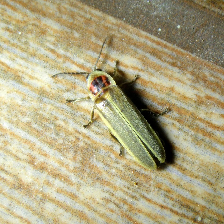

In [ ]:
img = image.load_img(img_path, target_size=(224, 224))
img

In [ ]:
X = image.img_to_array(img)
X = np.expand_dims(X, axis=0)

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
X = preprocess_input(X)
preds = modelo.predict(X)

1/1 [==============================] - 2s 2s/step


In [ ]:
preds.shape

(1, 5)

In [ ]:
preds

array([[0.02993339, 0.03458818, 0.85124636, 0.02114504, 0.06308704]],
      dtype=float32)

In [ ]:
np.argmax(preds, axis=1)

array([2])

### NO LA RECONOCÍA ANTERIORMENTE

---



In [ ]:
imgs, labels = next(test_data)

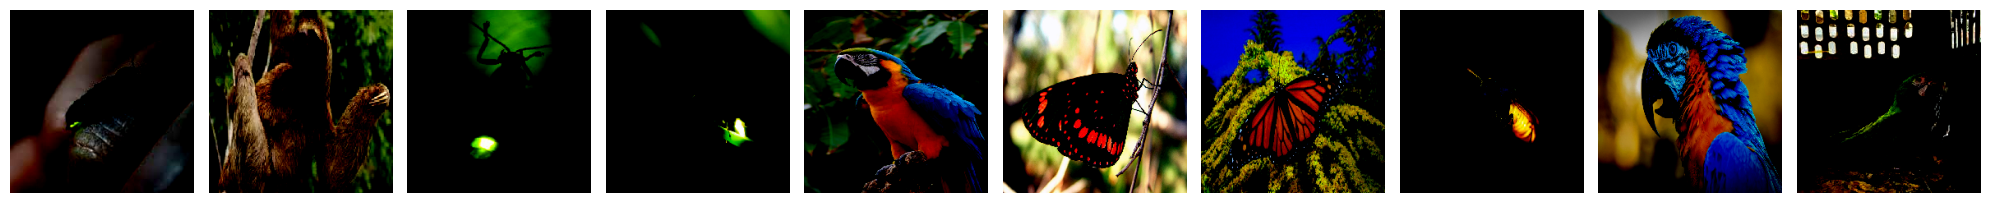

[[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [ ]:
plotImages(imgs)
print(labels)
# Etiquetas
# 0 => ajolote 1=>guacamaya 2=>luciernaga 3=>mariposa 4=>perezoso

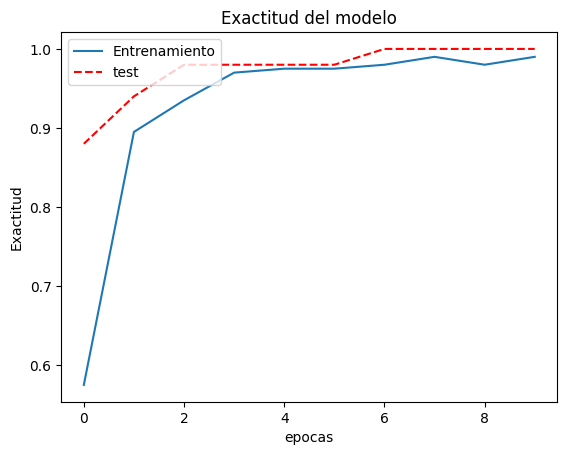

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'],'r--')
plt.title('Exactitud del modelo')
plt.ylabel('Exactitud')
plt.xlabel('epocas')
plt.legend(['Entrenamiento', 'test'], loc='upper left')
plt.show()

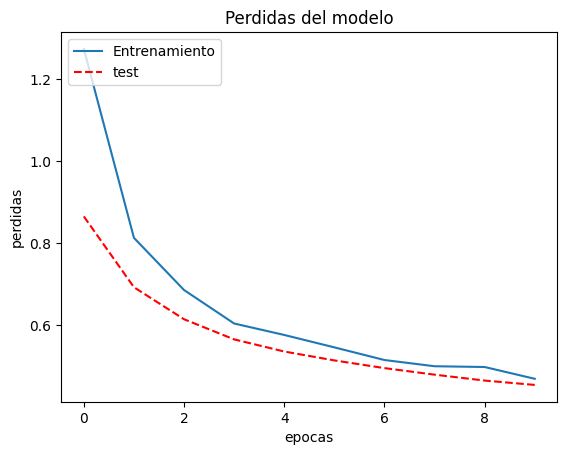

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'],'r--')
plt.title('Perdidas del modelo')
plt.ylabel('perdidas')
plt.xlabel('epocas')
plt.legend(['Entrenamiento', 'test'], loc='upper left')
plt.show()

# AJOLOTE

In [ ]:
img_path = '/content/drive/MyDrive/dataset/test/ajolote/ajolote41.jpg'

In [ ]:
img = image.load_img(img_path, target_size=(224, 224))

In [ ]:
X = image.img_to_array(img)
X = np.expand_dims(X, axis=0)

In [ ]:
X = preprocess_input(X)
preds = modelo.predict(X)

1/1 [==============================] - 0s 55ms/step


In [ ]:
preds.shape

(1, 5)

In [ ]:
preds

array([[0.64992684, 0.12680021, 0.09582996, 0.05254155, 0.07490145]],
      dtype=float32)

In [ ]:
np.argmax(preds, axis=1)

array([0])

### NO LO RECONOCÍA ANTERIORMENTE

In [ ]:
imgs, labels = next(test_data)

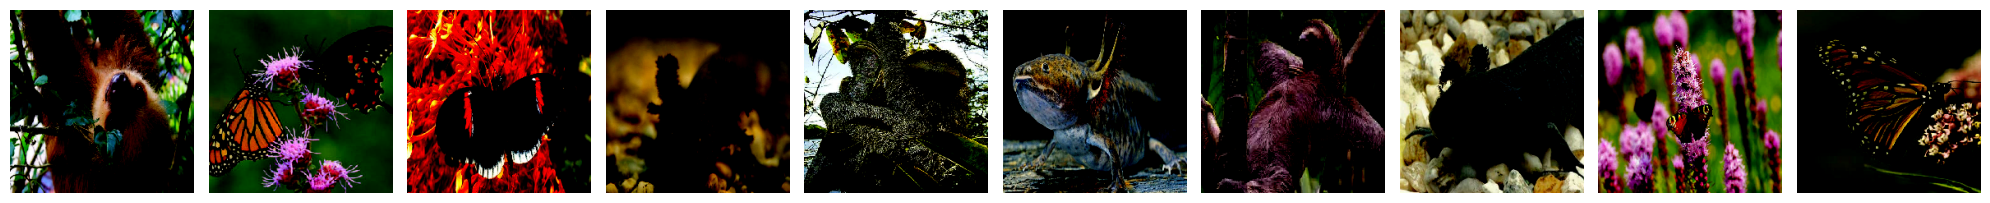

[[0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [ ]:
plotImages(imgs)
print(labels)
# Etiquetas
# 0 => ajolote 1=>guacamaya 2=>luciernaga 3=>mariposa 4=>perezoso

# Guacamaya

In [ ]:
img_path = '/content/drive/MyDrive/dataset/test/guacamaya/guacamaya41.jpg'

In [ ]:
img = image.load_img(img_path, target_size=(224, 224))

In [ ]:
X = image.img_to_array(img)
X = np.expand_dims(X, axis=0)

In [ ]:
X = preprocess_input(X)
preds = modelo.predict(X)

1/1 [==============================] - 0s 55ms/step


In [ ]:
preds.shape

(1, 5)

In [ ]:
preds

array([[0.15135051, 0.5642404 , 0.07844562, 0.09239583, 0.11356759]],
      dtype=float32)

In [ ]:
np.argmax(preds, axis=1)

array([1])

### LA RECONOCÍA ANTERIORMENTE

In [ ]:
imgs, labels = next(test_data)

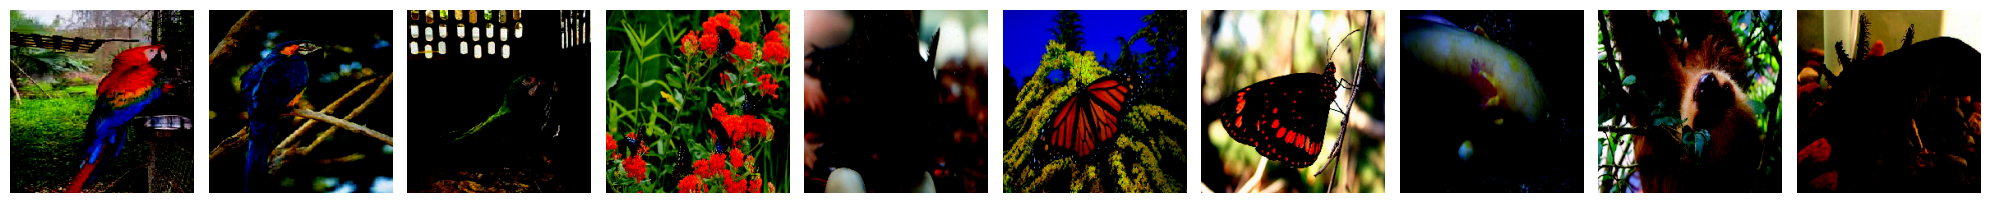

[[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [ ]:
plotImages(imgs)
print(labels)
# Etiquetas
# 0 => ajolote 1=>guacamaya 2=>luciernaga 3=>mariposa 4=>perezoso

# Mariposa

In [ ]:
img_path = '/content/drive/MyDrive/dataset/test/mariposa/mariposa41.jpg'

In [ ]:
img = image.load_img(img_path, target_size=(224, 224))

In [ ]:
X = image.img_to_array(img)
X = np.expand_dims(X, axis=0)

In [ ]:
X = preprocess_input(X)
preds = modelo.predict(X)

1/1 [==============================] - 0s 46ms/step


In [ ]:
preds.shape

(1, 5)

In [ ]:
preds

array([[0.06778746, 0.16894159, 0.20321421, 0.44334504, 0.11671169]],
      dtype=float32)

In [ ]:
np.argmax(preds, axis=1)

array([3])

### LA RECONOCÍA ANTERIORMENTE

In [ ]:
imgs, labels = next(test_data)

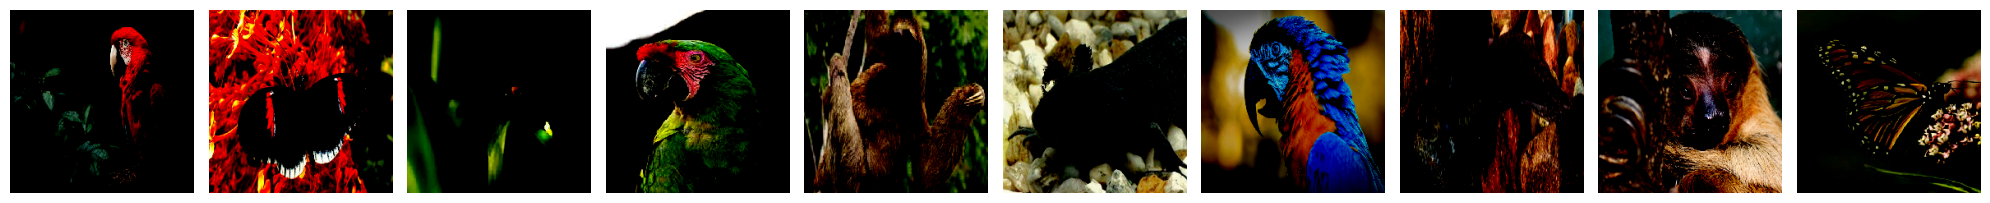

[[0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]]


In [ ]:
plotImages(imgs)
print(labels)
# Etiquetas
# 0 => ajolote 1=>guacamaya 2=>luciernaga 3=>mariposa 4=>perezoso

# Perezoso

In [ ]:
img_path = '/content/drive/MyDrive/dataset/test/perezoso/perezoso41.jpg'

In [ ]:
img = image.load_img(img_path, target_size=(224, 224))

In [ ]:
X = image.img_to_array(img)
X = np.expand_dims(X, axis=0)

In [ ]:
X = preprocess_input(X)
preds = modelo.predict(X)

1/1 [==============================] - 0s 38ms/step


In [ ]:
preds.shape

(1, 5)

In [ ]:
preds

array([[0.02157569, 0.04968043, 0.02995397, 0.02005385, 0.8787361 ]],
      dtype=float32)

In [ ]:
np.argmax(preds, axis=1)

array([4])

### LO RECONOCÍA ANTERIORMENTE

In [ ]:
imgs, labels = next(test_data)

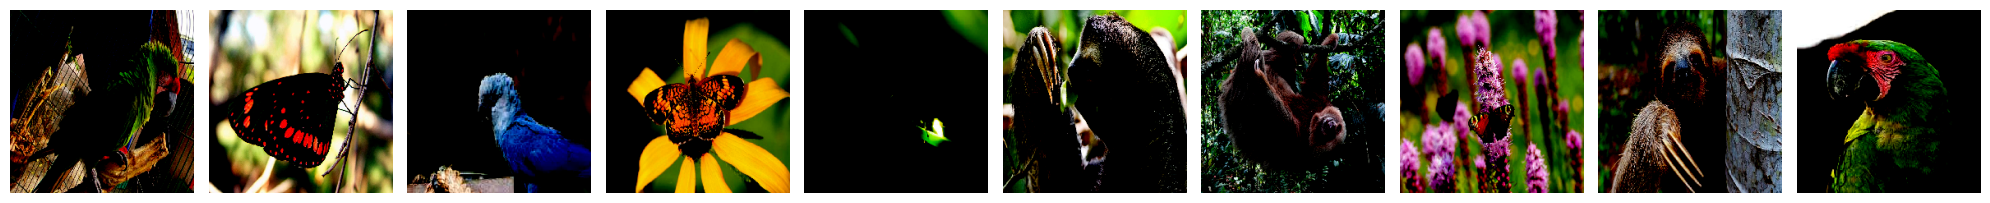

[[0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [ ]:
plotImages(imgs)
print(labels)
# Etiquetas
# 0 => ajolote 1=>guacamaya 2=>luciernaga 3=>mariposa 4=>perezoso